In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df = iris.frame.copy()

In [ ]:
# 3️⃣ İstersen species isimli sütunu ekle
df['species'] = df['target'].apply(lambda x: iris.target_names[x])

# 4️⃣ X ve y olarak ayır
X_iris = df[iris.feature_names]  # sadece özellikler
y_iris = df['species']           # hedef

In [ ]:
from sklearn.decomposition import PCA
model = PCA(n_components=2)
model.fit(X_iris)

PCA(n_components=2)

In [ ]:
X_2D=model.transform(X_iris)

In [ ]:
df['PCA1']=X_2D[:,0]
df['PCA2']=X_2D[:,1]

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,PCA1,PCA2
0,5.1,3.5,1.4,0.2,0,setosa,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,setosa,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,setosa,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,setosa,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,setosa,-2.728717,0.326755


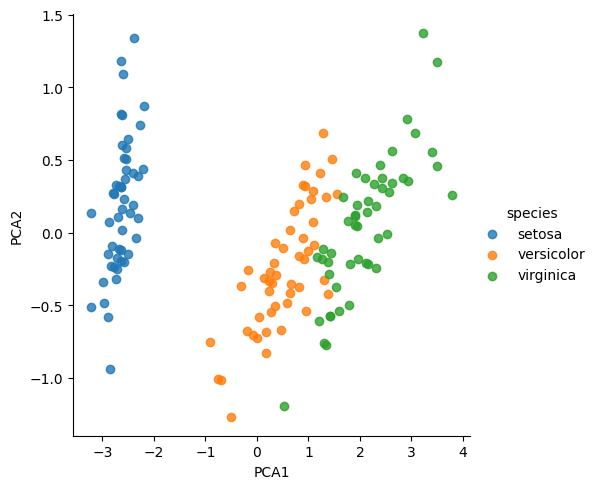

In [ ]:
import seaborn as sns
sns.lmplot(data=df,x='PCA1',y='PCA2',hue='species',fit_reg=False)

In [ ]:
from sklearn.mixture import GaussianMixture
model = GaussianMixture(n_components=3, covariance_type='full')
model.fit(X_iris)

GaussianMixture(n_components=3)

In [ ]:
y_gmm=model.predict(X_iris)

In [ ]:
df['clustering']=y_gmm

In [ ]:
df.head( )

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,PCA1,PCA2,clustering
0,5.1,3.5,1.4,0.2,0,setosa,-2.684126,0.319397,1
1,4.9,3.0,1.4,0.2,0,setosa,-2.714142,-0.177001,1
2,4.7,3.2,1.3,0.2,0,setosa,-2.888991,-0.144949,1
3,4.6,3.1,1.5,0.2,0,setosa,-2.745343,-0.318299,1
4,5.0,3.6,1.4,0.2,0,setosa,-2.728717,0.326755,1


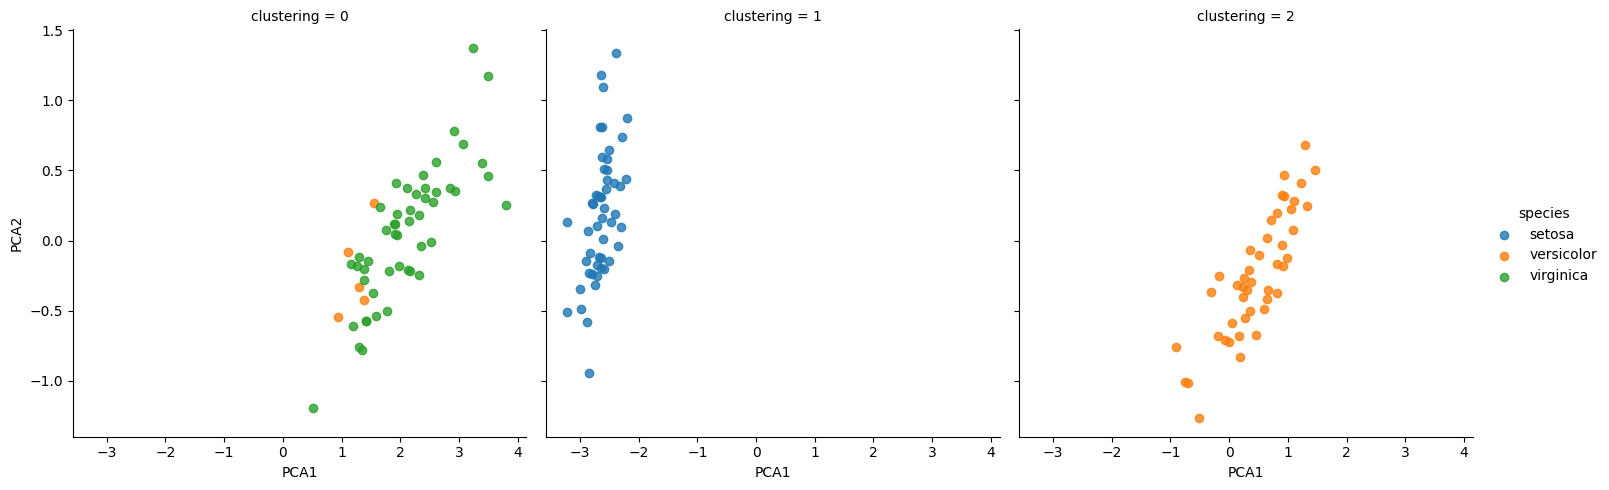

In [ ]:
sns.lmplot(data=df,x='PCA1',y='PCA2',hue='species', col='clustering',fit_reg=False)

In [ ]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt


In [ ]:
digits = load_digits()

In [ ]:
digits.images.shape

(1797, 8, 8)

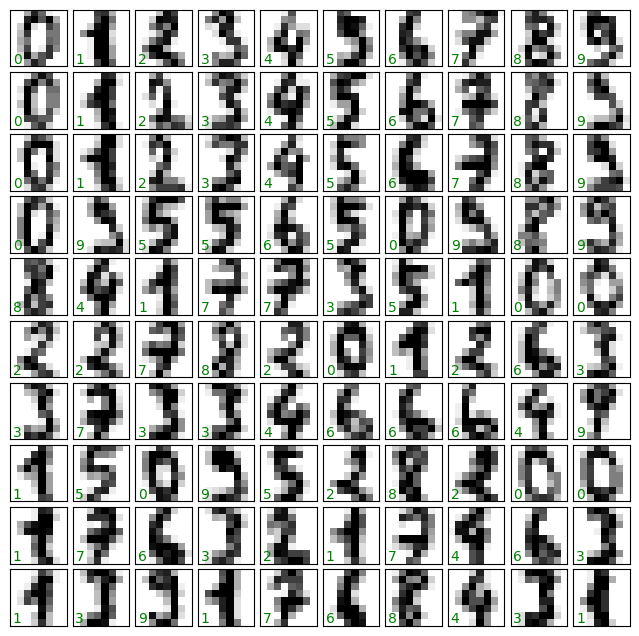

In [ ]:
fig, axes=plt.subplots(10,10, figsize=(8,8), subplot_kw={'xticks':[],'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),transform=ax.transAxes, color='green')

In [ ]:
X=digits.data
y=digits.target
print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [ ]:
from sklearn.manifold import Isomap
model = Isomap(n_components=2)
model.fit(X)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Isomap()

In [ ]:
data2=model.transform(X)
data2.shape

(1797, 2)

/tmp/ipykernel_3264/578590490.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(data2[:,0],data2[:,1],c=digits.target, alpha=0.5, cmap=plt.cm.get_cmap('tab10',10))


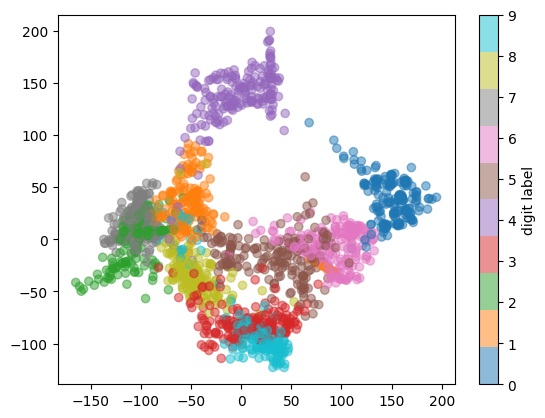

In [ ]:
plt.scatter(data2[:,0],data2[:,1],c=digits.target, alpha=0.5, cmap=plt.cm.get_cmap('tab10',10))
plt.colorbar(label='digit label' , ticks=range(10))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_model=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_model)

0.8333333333333334

In [ ]:
from sklearn.metrics import confusion_matrix
mat=confusion_matrix(y_test, y_model)

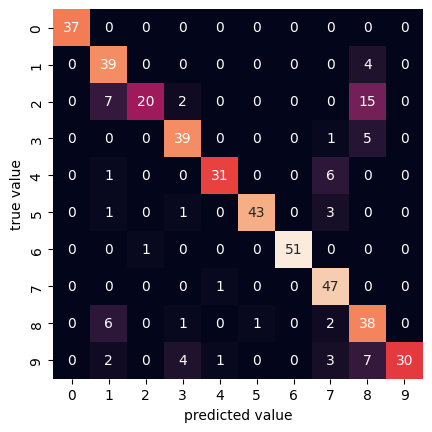

In [ ]:
sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value');